# Preparatory calculations for input parameters

In [2]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

from scipy.stats import linregress
from scipy.stats import norm

In [3]:
global_dpath = '~/work/hist_sst/data/'

# Historical calculations

In [4]:
ceres_tsel = slice(2001,2023)

## Forcing (ERF)

In [5]:
path = 'indicators_climatechange/forcing-timeseries-6.3.1/output/'
fname = 'ERF_ensemble.nc'
# ds_erf = xr.open_dataset(global_dpath + path + fname)
# erf_total = ds_erf.to_array("agent").sum("agent")
# erf_total.name = "ERF"
# erf_total

In [6]:
%%time
ds_erf = (
    xr.open_dataset(global_dpath + path + fname, 
                    engine="netcdf4")
    .sel(time=slice(1850,2024))
)

erf_total = 0
for v in ds_erf.data_vars:
    erf_total = erf_total + ds_erf[v]

erf_total = erf_total.rename("total")

CPU times: user 667 ms, sys: 8.67 s, total: 9.34 s
Wall time: 17.9 s


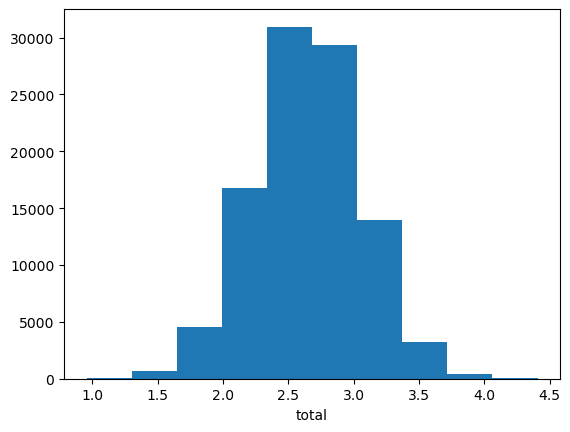

In [8]:
period_end = slice(2006,2024)
period_base = slice(1850,1900)
derf = (
    erf_total.sel(time=period_end ).mean(dim='time') - 
    erf_total.sel(time=period_base).mean(dim='time')
)

derf.plot.hist()
plt.show()

In [9]:
print(derf.quantile([0.05,0.50, 0.95]).values)
print(derf.std().values)
# derf.mean()

[1.97980555 2.65097938 3.31511532]
0.40630589084562474


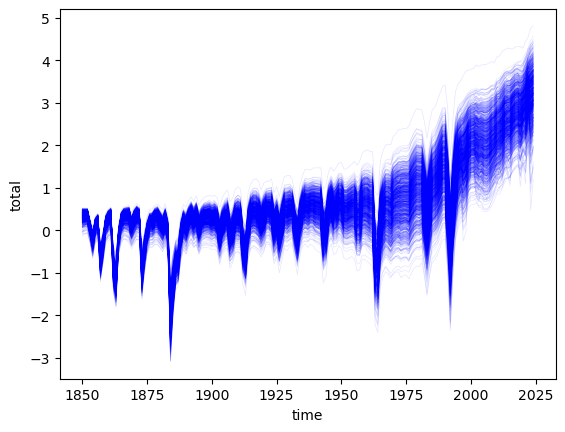

In [10]:
erf_total.isel(
    ensemble=np.random.choice(
        np.arange(len(erf_total.ensemble)), 
        size=1000, replace=False)
).plot.line(x='time',alpha=0.1,c='b',lw=0.5,add_legend=False)
plt.show()

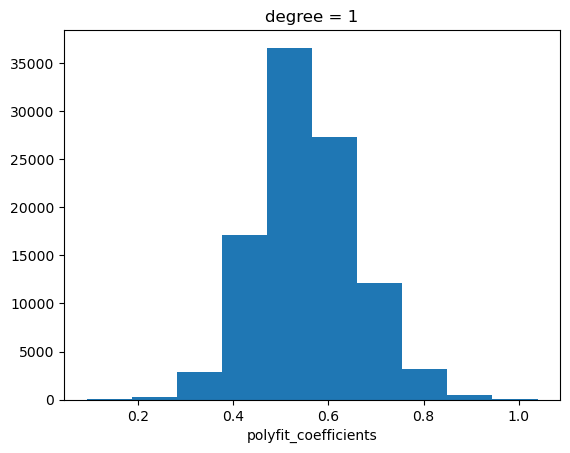

0.5557197156582815
0.10401695441496546
[0.398958   0.54754674 0.73782257]


In [11]:
dFdt = erf_total.sel(time=ceres_tsel).polyfit(dim='time',deg=1).polyfit_coefficients[0]
(10*dFdt).plot.hist()
plt.show()

print((10*dFdt.values).mean())
print((10*dFdt.values).std())
print((10*dFdt.quantile([0.05, 0.5, 0.95])).values)

## N (EEI): TOA imbalance

### IGCC

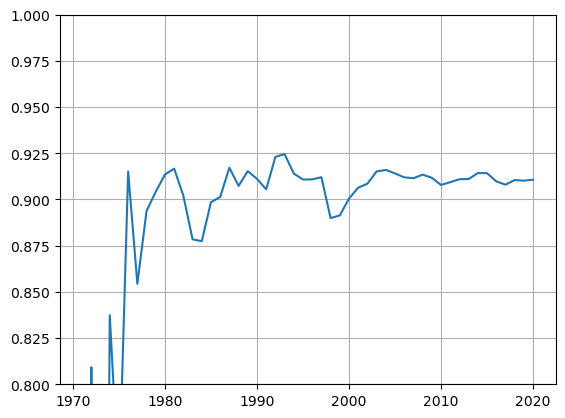

mean ratio = 0.9110372877690349


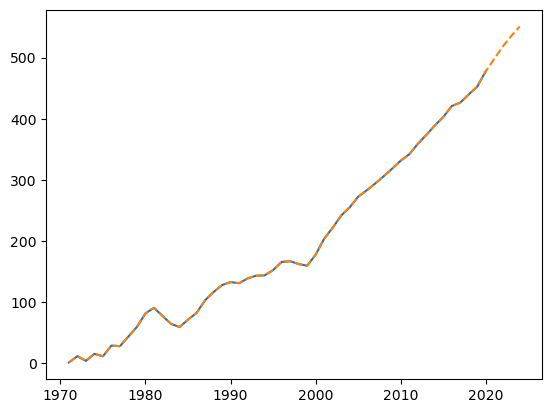

In [12]:
path = (global_dpath + 'indicators_climatechange/ClimateIndicator-data-2cd2409/' + 
        'data/earth_energy_imbalance/')
fname = 'earth_energy_imbalance.csv'
eei = pd.read_csv(path + fname)#[['time','timebound_lower','total']]
eei

plt.plot(eei.timebound_lower, eei['ocean_full-depth']/eei['total'])
plt.ylim(0.8,1)
plt.grid()
plt.show()

"""
https://essd.copernicus.org/articles/17/2641/2025/essd-17-2641-2025-supplement.pdf
To provide estimates of the EEI up to the year 2024, we scale up the values of OHC change in 2021, 2022, 2023 and 2024 to232
reflect the ~ 90 % contribution of the ocean to changes in the Earth heat inventory. The EEI is then simply computed as the233
difference in global energy inventory over each period, converted to units of watts per square metre (W m−2) using the surface234
area of the Earth and the elapsed time.
"""
## follow this method
plt.plot(eei.timebound_lower, eei.total)

## get the mean ratio over last 10 years
n=15
temp = eei['ocean_full-depth']/eei['total']
temp = temp.dropna()[-n:]
mean_ratio = temp.mean()
print('mean ratio =', mean_ratio)
eei.loc[50:,'total'] = eei[-4:]['ocean_full-depth'].values/mean_ratio
plt.plot(eei.timebound_lower, eei.total,ls='--')
plt.show()


In [13]:
print('show relationship between ocean energy inventory anomalies and total anomalies')
print((eei['ocean_full-depth'] / eei['total']).iloc[-10:])

## scale this by 1/.91
ocean_scalef = (eei['ocean_full-depth'] / eei['total']).iloc[-1]
print(ocean_scalef)

## DO NOT SCALE THE ERROR: the Indicators page does not do this
## note however it is impossible to reproduce their final range 2015-2024
# eei_totalerror = eei['ocean_full-depth_error']/ocean_scalef
eei_totalerror = eei['ocean_full-depth_error'] 

show relationship between ocean energy inventory anomalies and total anomalies
44    0.914204
45    0.909805
46    0.907990
47    0.910499
48    0.910170
49    0.910694
50    0.911037
51    0.911037
52    0.911037
53    0.911037
dtype: float64
0.911037287769035


final year is 2006-2024


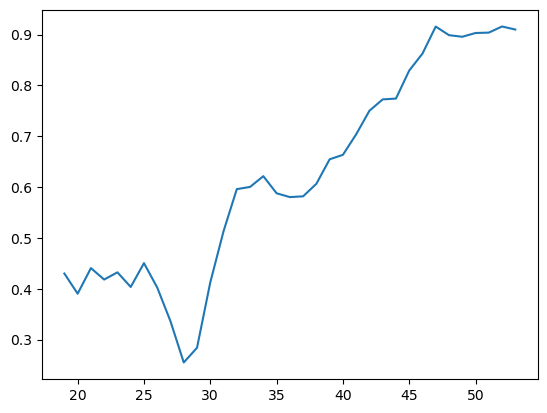

In [14]:
## Convert ZJ to rolling 17 year mean W/m2
nyr = 19 # use eighteen to just extend sherwood period to 2006--2023

## change in energy inventory
dZJ = eei['total'][nyr:] - eei['total'][:-nyr].values
# print(dZJ)

## convert to W/m2 over interval
# ndays = pd.date_range('2012-12-31','2024-12-31',freq='D').size/(nyr)
# print(ndays)
dt = 24*3600*365.25*nyr # seconds in nyr
aoe = 5.1006e14 # meters
Zfactor = 1e21
eei_wm2 = dZJ / dt * Zfactor / aoe

# print('final year is 2007-2024')
print('final year is 2006-2024')
plt.plot(eei_wm2)
plt.show()

0.7158618505907142
0.7160273984699765
0.710018981338576


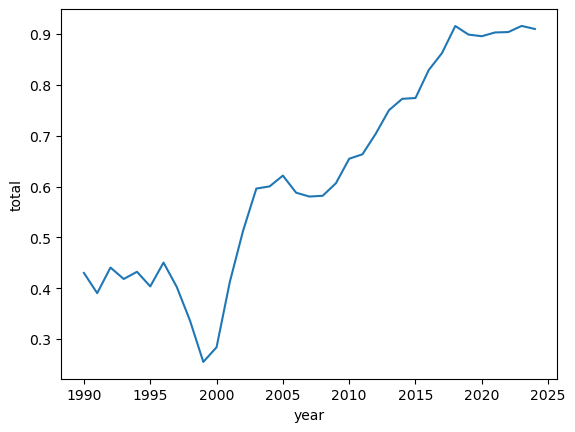

In [15]:
eei_wm2_da = xr.DataArray(eei_wm2, dims='year')
eei_wm2_da['year'] = np.arange(1971+nyr,2024+1,1)
print(eei_wm2_da.sel(year=2018).values - 0.2)
print(eei_wm2_da.sel(year=2023).values - 0.2)
print(eei_wm2_da.sel(year=2024).values - 0.2)
eei_wm2_da.plot()

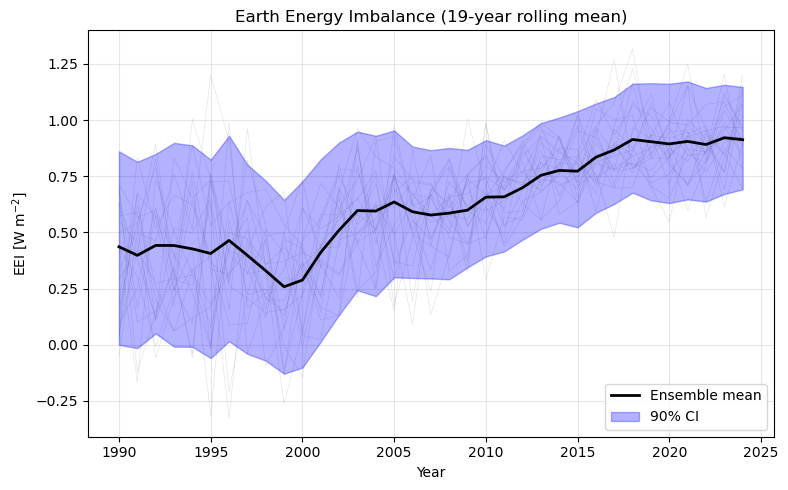

2018 ensemble mean: 0.914 W/m²
2018 range (90% CI): [0.677, 1.162]

2023 ensemble mean: 0.921 W/m²
2023 range (90% CI): [0.671, 1.157]

2024 ensemble mean: 0.913 W/m²
2024 range (90% CI): [0.692, 1.157]


In [16]:
## Convert ZJ to rolling 17 year mean W/m2 with uncertainty propagation
nyr = 19
n_ens = 1000  # number of ensemble members

## Set random seed for reproducibility (optional)
np.random.seed(42)

## Draw z-scores for each ensemble member and each time point
# Option 1: Fully independent errors at each time
z_scores = np.random.randn(n_ens, len(eei))

# Option 2: Partially correlated errors (more realistic)
# Each ensemble member gets a persistent bias + independent noise
# z_bias = np.random.randn(n_ens, 1) * 0.5  # systematic component
# z_noise = np.random.randn(n_ens, len(eei)) * np.sqrt(1 - 0.5**2)  # independent component
# z_scores = z_bias + z_noise

# Option 3: Fully correlated errors (same z-score for all times within an ensemble member)
# This means each ensemble member is a consistent offset throughout
# BAD
# z_scores = np.random.randn(n_ens, 1) * np.ones((1, len(eei)))

## Create ensemble of total EEI including uncertainty
eei_total_ens = eei['total'].values[np.newaxis, :] + z_scores * eei_totalerror.values[np.newaxis, :]
# Shape: (n_ens, n_time)

## Calculate change in energy inventory for ensemble
dZJ_ens = eei_total_ens[:, nyr:] - eei_total_ens[:, :-nyr]
# Shape: (n_ens, n_time - nyr)

## Convert to W/m2 over interval
dt = 24*3600*365.25*nyr  # seconds in nyr
aoe = 5.1006e14  # meters
Zfactor = 1e21
eei_wm2_ens = dZJ_ens / dt * Zfactor / aoe

## Create xarray DataArray with ensemble dimension
eei_wm2_da_ens = xr.DataArray(
    eei_wm2_ens, 
    dims=['ens', 'year'],
    coords={
        'ens': np.arange(n_ens),
        'year': np.arange(1971+nyr, 2024+1, 1)
    }
)

## Calculate central estimate (mean of ensemble)
eei_wm2_da = eei_wm2_da_ens.mean(dim='ens')

## Calculate confidence intervals
eei_wm2_da_lower = eei_wm2_da_ens.quantile(0.05, dim='ens')  # 5th percentile
eei_wm2_da_upper = eei_wm2_da_ens.quantile(0.95, dim='ens')  # 95th percentile

## Visualize
fig, ax = plt.subplots(figsize=(8, 5))

# Plot ensemble members (show subset for clarity)
for i in range(min(20, n_ens)):
    ax.plot(eei_wm2_da_ens.year, eei_wm2_da_ens.isel(ens=i), 
            c='gray', alpha=0.2, lw=0.5, zorder=1)

# Plot mean and confidence interval
ax.plot(eei_wm2_da.year, eei_wm2_da, 'k-', lw=2, label='Ensemble mean', zorder=3)
ax.fill_between(eei_wm2_da.year, eei_wm2_da_lower, eei_wm2_da_upper, 
                alpha=0.3, color='blue', label='90% CI', zorder=2)

ax.set_xlabel('Year')
ax.set_ylabel('EEI [W m$^{-2}$]')
ax.set_title(f'Earth Energy Imbalance ({nyr}-year rolling mean)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Print values for comparison
print(f'2018 ensemble mean: {eei_wm2_da.sel(year=2018).values:.3f} W/m²')
print(f'2018 range (90% CI): [{eei_wm2_da_lower.sel(year=2018).values:.3f}, {eei_wm2_da_upper.sel(year=2018).values:.3f}]')
print(f'\n2023 ensemble mean: {eei_wm2_da.sel(year=2023).values:.3f} W/m²')
print(f'2023 range (90% CI): [{eei_wm2_da_lower.sel(year=2023).values:.3f}, {eei_wm2_da_upper.sel(year=2023).values:.3f}]')
print(f'\n2024 ensemble mean: {eei_wm2_da.sel(year=2024).values:.3f} W/m²')
print(f'2024 range (90% CI): [{eei_wm2_da_lower.sel(year=2024).values:.3f}, {eei_wm2_da_upper.sel(year=2023).values:.3f}]')

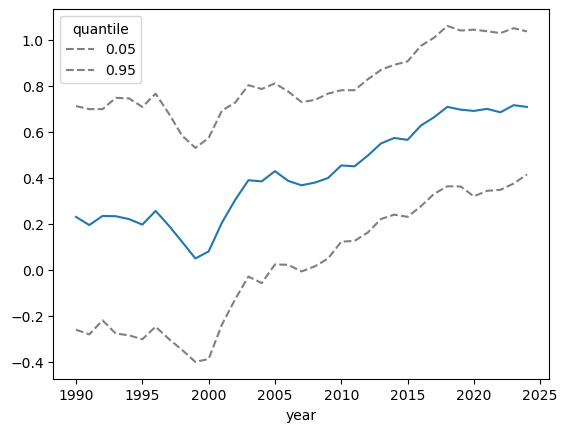

In [17]:
## Define preindustrial baseline (following Sherwood)
N_PI_mean = 0.2  # W/m²
N_PI_std = 0.2 / 1.645  # convert 5-95% range (0 to 0.4) to 1σ ≈ 0.12 W/m²

## Draw preindustrial baseline for each ensemble member (constant in time)
N_PI_ens = np.random.randn(n_ens) * N_PI_std + N_PI_mean

## Calculate ΔN = N_recent - N_PI for each ensemble member
deltaN_ens = eei_wm2_da_ens - N_PI_ens[:, np.newaxis]  # broadcast over time

## Add internal variability (independent for each year)
sigma_iv = 0.07  # W/m², from Sherwood
internal_var = np.random.randn(n_ens, len(eei_wm2_da.year)) * sigma_iv

## Total anomaly with all uncertainty sources
deltaN_total_ens = deltaN_ens + internal_var

## Convert to xarray
deltaN_da_ens = xr.DataArray(
    deltaN_total_ens,
    dims=['ens', 'year'],
    coords={'ens': np.arange(n_ens), 'year': eei_wm2_da.year}
)

# Sherwood's quadrature formula:
# σ(ΔN)² = σ(recent)² + σ(PI)² + σ(IV)²

# Your Monte Carlo implicitly does this because:
# - recent measurement: independent draws each year
# - PI baseline: independent draw per ensemble (constant offset)
# - internal variability: independent draws each year
# → Total variance = sum of component variances

deltaN_da_ens.mean(dim='ens').plot.line(x='year')
deltaN_da_ens.quantile([.05,.95],dim='ens').plot.line(x='year',c='gray',ls='--')
plt.show()

In [18]:
# Load EEI table
path = (
    global_dpath
    + 'indicators_climatechange/ClimateIndicator-data-2cd2409/'
    + 'data/earth_energy_imbalance/'
)
fname = 'earth_energy_imbalance.csv'
eei = pd.read_csv(path + fname).copy()

# ------------------------------------------------------------
# Reconstruct recent total heat inventory the same way as above
# ------------------------------------------------------------
n_ratio = 15
ratio = eei['ocean_full-depth'] / eei['total']
mean_ratio = ratio.dropna().iloc[-n_ratio:].mean()

# Fill any missing total values from ocean_full-depth / mean_ratio
missing_total = eei['total'].isna()
eei.loc[missing_total, 'total'] = eei.loc[missing_total, 'ocean_full-depth'] / mean_ratio

print(f'mean ocean/total ratio used for recent back-fill = {mean_ratio:.6f}')

# ------------------------------------------------------------
# Constants
# ------------------------------------------------------------
aoe = 5.1006e14   # m^2
Zfactor = 1e21
z95 = 1.6448536269514722  # Gaussian central 90% interval

def period_eei_random(df, start_year, end_year):
    """
    Literal endpoint difference:
    use row with timebound_lower == start_year and end_year
    
    Central estimate:
        (total[end] - total[start]) / elapsed_time
    
    Uncertainty:
        fully random endpoint errors using ocean_full-depth_error directly
        sigma_dZJ = sqrt(sig_start^2 + sig_end^2)
    """
    row0 = df.loc[df['timebound_lower'] == start_year].iloc[0]
    row1 = df.loc[df['timebound_lower'] == end_year].iloc[0]

    nyr = end_year - start_year
    dt = 24 * 3600 * 365.25 * nyr
    factor = Zfactor / dt / aoe

    dzj = row1['total'] - row0['total']
    eei_wm2 = dzj * factor

    sig0 = row0['ocean_full-depth_error']
    sig1 = row1['ocean_full-depth_error']
    sigma_dzj = np.sqrt(sig0**2 + sig1**2)
    sigma_wm2 = sigma_dzj * factor

    lo = eei_wm2 - z95 * sigma_wm2
    hi = eei_wm2 + z95 * sigma_wm2

    return {
        'period': f'{start_year}-{end_year}',
        'nyr': nyr,
        'start_total_ZJ': row0['total'],
        'end_total_ZJ': row1['total'],
        'start_ocean_error_ZJ': sig0,
        'end_ocean_error_ZJ': sig1,
        'EEI_Wm2': eei_wm2,
        'p05_Wm2': lo,
        'p95_Wm2': hi,
        'half_width_Wm2': z95 * sigma_wm2,
    }

# ------------------------------------------------------------
# Requested periods
# ------------------------------------------------------------
periods = [
    (1975, 1994),
    (1995, 2014),
    (2005, 2023),   # your corrected final period
    (2005, 2024),   # your corrected final period
]

rows = [period_eei_random(eei, y0, y1) for y0, y1 in periods]
df_eei_periods = pd.DataFrame(rows)

display(
    df_eei_periods[
        [
            'period',
            'nyr',
            'EEI_Wm2',
            'p05_Wm2',
            'p95_Wm2',
            'half_width_Wm2',
        ]
    ].round(3)
)

print('\nDetailed endpoint values:')
display(
    df_eei_periods[
        [
            'period',
            'start_total_ZJ',
            'end_total_ZJ',
            'start_ocean_error_ZJ',
            'end_ocean_error_ZJ',
        ]
    ].round(3)
)


mean ocean/total ratio used for recent back-fill = 0.911037


,period,nyr,EEI_Wm2,p05_Wm2,p95_Wm2,half_width_Wm2
0,1975-1994,19,0.432,-0.013,0.878,0.446
1,1995-2014,19,0.773,0.535,1.010,0.238
2,2005-2023,18,0.907,0.668,1.146,0.239
3,2005-2024,19,0.910,0.679,1.141,0.231



Detailed endpoint values:


,period,start_total_ZJ,end_total_ZJ,start_ocean_error_ZJ,end_ocean_error_ZJ
0,1975-1994,11.754,143.927,75.314,34.561
1,1995-2014,152.558,388.823,35.826,25.868
2,2005-2023,272.505,535.292,23.100,35.287
3,2005-2024,272.505,550.816,23.100,36.161


In [19]:
## already prepared this to make 2024 be 2006-2024
print('mean', deltaN_ens.sel(year=2024).mean().round(3).values)
print('st d', deltaN_ens.sel(year=2024).std(ddof=1).round(3).values)

## better final version, but basically same
## Define preindustrial baseline (following Sherwood)
print(N_PI_mean)
print(N_PI_std)

## Add internal variability (based on X year periods)
sigma_iv = 0.07  # W/m², from Sherwood

## note this period is actually 2006-2024, inclusive
eei_2006_to_2023_mean = df_eei_periods.loc[df_eei_periods['period'] == '2005-2024']['EEI_Wm2'].values
print(eei_2006_to_2023_mean)
eei_2006_to_2023_std = df_eei_periods.loc[df_eei_periods['period'] == '2005-2024']['half_width_Wm2'].values / 1.645
print(eei_2006_to_2023_std)

final_dN_2006to2023_mean = eei_2006_to_2023_mean - N_PI_mean
final_dN_2006to2023_std = (eei_2006_to_2023_std**2 + sigma_iv**2 + N_PI_std**2)**0.5

print(final_dN_2006to2023_mean, final_dN_2006to2023_std)

mean 0.706
st d 0.18
0.2
0.12158054711246201
[0.91001898]
[0.14029213]
[0.71001898] [0.1984029]


### CERES

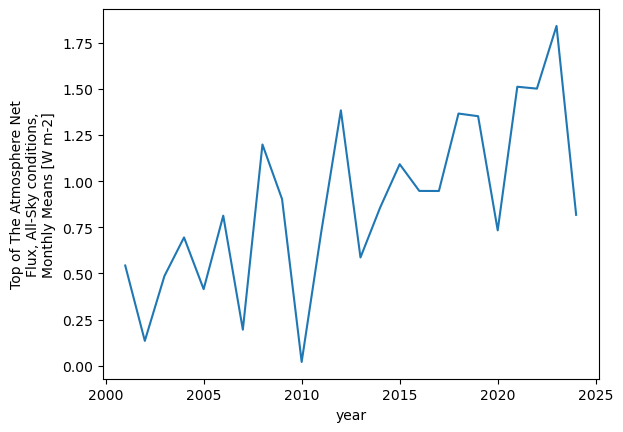

In [20]:
path = 'ceres_ebaf/ceres_ebaf/dl_20260602_globalmeanTOA/'
fname = 'CERES_EBAF_Ed4.2.1_Subset_200003-202512.nc'
ceres = xr.open_dataset(global_dpath + path + fname).sel(
    time=slice('2001-01-01','2024-12-31')).groupby('time.year').mean()
ceres['gtoa_net_all_mon'].plot()

plt.show()

In [21]:
ceres_lr = linregress(x = ceres['gtoa_net_all_mon'].sel(year=ceres_tsel).year, 
                      y = ceres['gtoa_net_all_mon'].sel(year=ceres_tsel))
print(ceres_lr.slope*10)
print(ceres_lr.stderr*10)

0.5154949892312288
0.10398959424684978


## Temperature

In [22]:
gmst_path = Path(global_dpath + "ar7-gmst-ensemble/sst_pseudo_ipcc.csv")

gmst_df = pd.read_csv(gmst_path, header=None)

gmst_ens = xr.DataArray(
    gmst_df.iloc[:, 1:].to_numpy(dtype="float32"),
    dims=("year", "ensemble"),
    coords={
        "year": gmst_df.iloc[:, 0].astype(int).to_numpy(),
        "ensemble": np.arange(gmst_df.shape[1] - 1),
    },
    name="gmst",
    attrs={"units": "degC", "baseline": "1850-1900"},
)

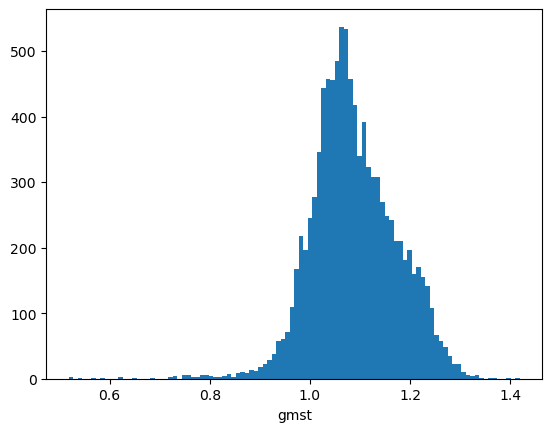

In [22]:
dT = (
    gmst_ens.sel(year=period_end ).mean(dim='year') - 
    gmst_ens.sel(year=period_base).mean(dim='year')
)

dT.plot.hist(bins=100)
plt.show()

In [23]:
print(dT.quantile([0.05,0.50, 0.95]).values)
print(dT.std().values)
print(dT.mean().values)

print(dT.quantile([0.05]).values - dT.quantile([0.5]).values)
print(dT.quantile([0.95]).values - dT.quantile([0.5]).values)

[0.96716547 1.07917619 1.2326984 ]
0.08415429
1.0879259
[-0.11201071]
[0.15352221]


In [24]:
## C25 and Thorne / AR7 have very similar 1sigma
print(np.sqrt(0.10**2+0.07**2))
print(np.sqrt(0.084**2+0.07**2))

0.12206555615733704
0.10934349546269317


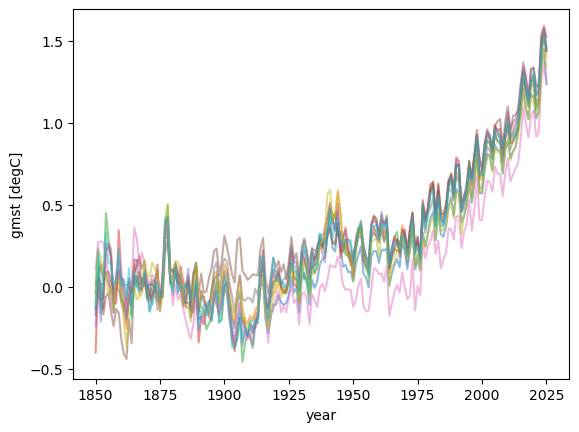

In [25]:
## confirm that errors are temporally correlated
gmst_ens.isel(ensemble=slice(10,20)).plot.line(
    x='year',alpha=0.5,add_legend=False)
plt.show()

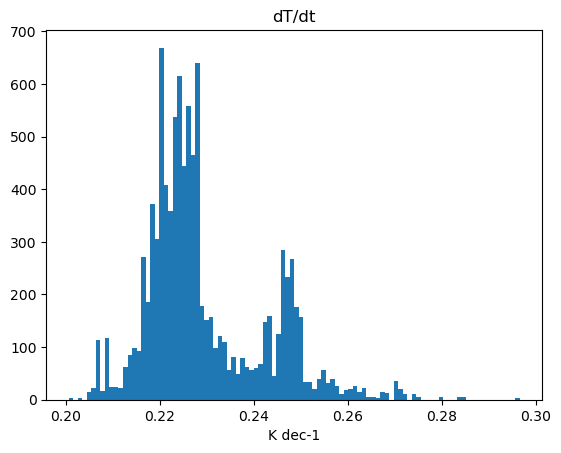

0.22940693463361367
0.012767108066559776
[0.21396199 0.22575741 0.25152167]


In [165]:
dTdt = gmst_ens.sel(year=ceres_tsel).polyfit(dim='year',deg=1).polyfit_coefficients[0]
(10*dTdt).plot.hist(density=False,bins=100)
plt.title('dT/dt')
plt.xlabel('K dec-1')
plt.show()

print((10*dTdt.values).mean())
print((10*dTdt.values).std())
print((10*dTdt.quantile([0.05,0.5,0.95])).values)



#### CERES params and likelihood

In [150]:
mc_n = 1000000

dTdt_mu  = dTdt.mean() # doesnt account for skewness
dTdt_sig = dTdt.std(ddof=1) # doesnt account for skewness
dTdt_mc = np.random.choice(dTdt, size=mc_n, replace=True)

dFdt_mc = np.random.choice(dFdt, size=mc_n, replace=True)
additional_dF_error = 0.15/10 # 0.1 W/m2/dec
dFdt_mc += additional_dF_error*np.random.randn(mc_n)

dNdt_mu = ceres_lr.slope
dNdt_sig = ceres_lr.stderr
dNdt_mc = dNdt_mu + dNdt_sig*np.random.randn(mc_n)

dlamb_mu = 0.
dlamb_sig = 0.3
dlamb_mc = dlamb_mu + dlamb_sig*np.random.randn(mc_n)

F2x_mc = 3.93 + 0.29*np.random.randn(mc_n)

In [151]:
## internal variability in N and T from 24 year trends (cesm2 picontrol)
## needs to be adjusted into annual at the end to match other units
rng = np.random.default_rng(seed=123)

N_iv_sig = 0.10  ## w m-2 dec-1
T_iv_sig = 0.05  ## k dec-1
cov_T_N_iv = -0.0017 ## small anticorrelation 
# cov_T_N_iv = 0.

iv_cov = np.array(
    [
        [N_iv_sig**2, cov_T_N_iv],
        [cov_T_N_iv, T_iv_sig**2],
    ]
)

iv = rng.multivariate_normal(
    mean=[0.0, 0.0],
    cov=iv_cov,
    size=mc_n,
)

# fix units to be annual
N_iv = iv[:, 0]/10
T_iv = iv[:, 1]/10

# reset with iv included
dNdt_mc = dNdt_mu + dNdt_sig*np.random.randn(mc_n) + N_iv
dTdt_mc = np.random.choice(dTdt, size=mc_n, replace=True) + T_iv

## include int var in the sigmas that are scored
dNdt_sig_adj = (dNdt_sig**2 + (N_iv_sig/10)**2)**0.5
dTdt_sig_adj = (dTdt_sig**2 + (T_iv_sig/10)**2)**0.5

In [201]:
xmax = 12
S_grid = np.linspace(0.05, xmax, 100)

likelihood_dN = []
likelihood_dT = []
likelihood_joint_dNdT = []

# for i,s in enumerate(S_grid):
#     lamb_mc = -F2x_mc / s
#     lamb_eff_mc = lamb_mc - dlamb_mc

#     ## score observed dN/dt, treating dF/dt and dT/dt as nuisance
#     dNdt_pred = dFdt_mc + lamb_eff_mc * dTdt_mc
#     p_dN = norm.pdf(dNdt_mu, loc=dNdt_pred, scale=dNdt_sig_adj)
#     likelihood_dN.append(np.nanmean(p_dN))

#     ## score observed dT/dt, treating dF/dt and dN/dt as nuisance
#     dTdt_pred = -(dFdt_mc - dNdt_mc) / lamb_eff_mc
#     p_dT = norm.pdf(dTdt_mu, loc=dTdt_pred, scale=dTdt_sig_adj)
#     likelihood_dT.append(np.nanmean(p_dT))
#     if i==20:
#         p_dN_20 = p_dN.copy()
#         p_dT_20 = p_dT.copy()
#     if i==50:
#         p_dN_50 = p_dN.copy()
#         p_dT_50 = p_dT.copy()
#     elif i==90:
#         p_dN_90 = p_dN.copy()
#         p_dT_90 = p_dT.copy()

# likelihood_dN = np.array(likelihood_dN)
# likelihood_dN = likelihood_dN / likelihood_dN.max()

# likelihood_dT = np.array(likelihood_dT)
# likelihood_dT = likelihood_dT / likelihood_dT.max()

## option to do l likelihood instead
xmax = 4
l_grid = np.linspace(-xmax, xmax, 100)
for i,l in enumerate(l_grid):
    
    lamb_eff_mc = l - dlamb_mc

    ## score observed dN/dt, treating dF/dt and dT/dt as nuisance
    dNdt_pred = dFdt_mc + lamb_eff_mc * dTdt_mc
    p_dN = norm.pdf(dNdt_mu, loc=dNdt_pred, scale=dNdt_sig_adj)
    likelihood_dN.append(np.nanmean(p_dN))

    ## score observed dT/dt, treating dF/dt and dN/dt as nuisance
    dTdt_pred = -(dFdt_mc - dNdt_mc) / lamb_eff_mc
    p_dT = norm.pdf(dTdt_mu, loc=dTdt_pred, scale=dTdt_sig_adj)
    likelihood_dT.append(np.nanmean(p_dT))
    if i==20:
        p_dN_20 = p_dN.copy()
        p_dT_20 = p_dT.copy()
    if i==50:
        p_dN_50 = p_dN.copy()
        p_dT_50 = p_dT.copy()
    elif i==90:
        p_dN_90 = p_dN.copy()
        p_dT_90 = p_dT.copy()

likelihood_dN = np.array(likelihood_dN)
likelihood_dN = likelihood_dN / likelihood_dN.max()

likelihood_dT = np.array(likelihood_dT)
likelihood_dT = likelihood_dT / likelihood_dT.max()

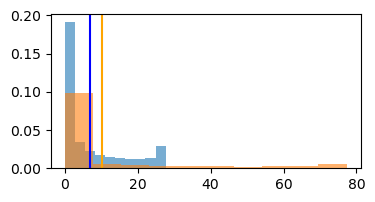

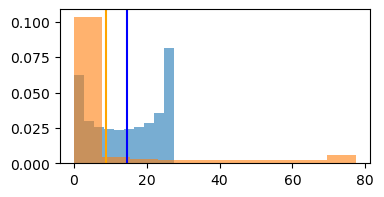

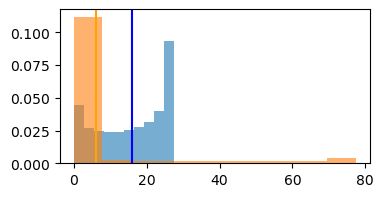

In [195]:
plt.subplots(figsize=(4,2))
plt.hist(p_dN_20,alpha=0.6,density=True)
plt.hist(p_dT_20,alpha=0.6,density=True)
plt.axvline(p_dN_20.mean(),c='b')
plt.axvline(p_dT_20.mean(),c='orange')
plt.show()

plt.subplots(figsize=(4,2))
plt.hist(p_dN_50,alpha=0.6,density=True)
plt.hist(p_dT_50,alpha=0.6,density=True)
plt.axvline(p_dN_50.mean(),c='b')
plt.axvline(p_dT_50.mean(),c='orange')
plt.show()

plt.subplots(figsize=(4,2))
plt.hist(p_dN_90,alpha=0.6,density=True)
plt.hist(p_dT_90,alpha=0.6,density=True)
plt.axvline(p_dN_90.mean(),c='b')
plt.axvline(p_dT_90.mean(),c='orange')
plt.show()

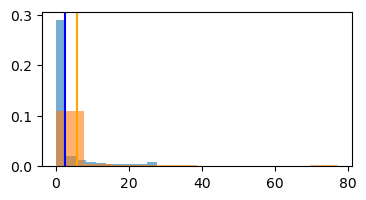

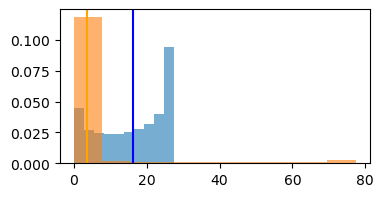

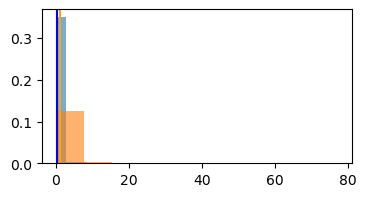

In [205]:
plt.subplots(figsize=(4,2))
plt.hist(p_dN_20,alpha=0.6,density=True)
plt.hist(p_dT_20,alpha=0.6,density=True)
plt.axvline(p_dN_20.mean(),c='b')
plt.axvline(p_dT_20.mean(),c='orange')
plt.show()

plt.subplots(figsize=(4,2))
plt.hist(p_dN_50,alpha=0.6,density=True)
plt.hist(p_dT_50,alpha=0.6,density=True)
plt.axvline(p_dN_50.mean(),c='b')
plt.axvline(p_dT_50.mean(),c='orange')
plt.show()

plt.subplots(figsize=(4,2))
plt.hist(p_dN_90,alpha=0.6,density=True)
plt.hist(p_dT_90,alpha=0.6,density=True)
plt.axvline(p_dN_90.mean(),c='b')
plt.axvline(p_dT_90.mean(),c='orange')
plt.show()

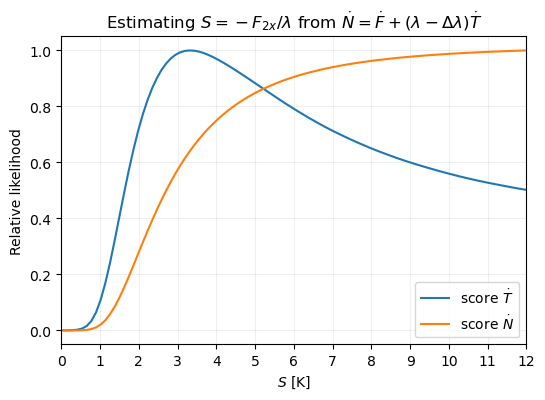

In [169]:
## Plot
plt.subplots(figsize=(6,4))
plt.plot(S_grid, likelihood_dT, label="score $\dot{T}$")
plt.plot(S_grid, likelihood_dN, label="score $\dot{N}$")
# plt.plot(S_grid, likelihood_joint_dNdT, label="joint dN/dt, dT/dt",ls='--')
plt.legend()
plt.grid(alpha=0.2)
plt.xticks(np.arange(xmax + 1))
plt.xlim(0, xmax)
plt.ylabel("Relative likelihood")
plt.title(
    'Estimating $S=-F_{2x} / \lambda$ from $\dot{N} = \dot{F} + (\lambda - \Delta \lambda)\dot{T}$'
)
plt.xlabel("$S$ [K]")
plt.show()

In [208]:
F2x_mc

array([3.96411334, 3.38968723, 4.02296138, ..., 3.78017938, 3.62292478,
       4.05787672])

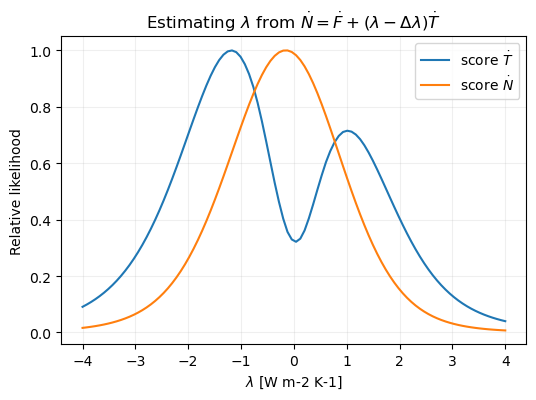

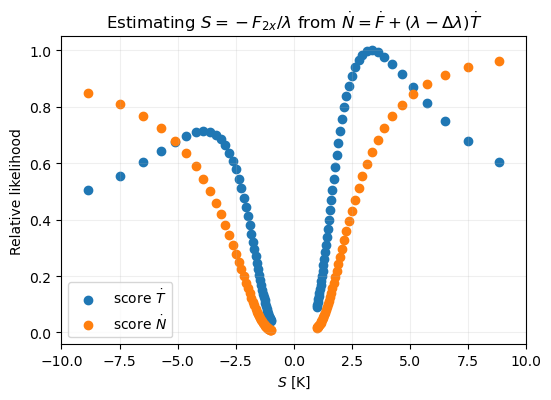

In [217]:
## Plot
plt.subplots(figsize=(6,4))
plt.plot(l_grid, likelihood_dT, label="score $\dot{T}$")
plt.plot(l_grid, likelihood_dN, label="score $\dot{N}$")
# plt.plot(S_grid, likelihood_joint_dNdT, label="joint dN/dt, dT/dt",ls='--')
plt.legend()
plt.grid(alpha=0.2)
# plt.xticks(np.arange(xmax + 1))
# plt.xlim(0, xmax)
plt.ylabel("Relative likelihood")
plt.title(
    'Estimating $\lambda$ from $\dot{N} = \dot{F} + (\lambda - \Delta \lambda)\dot{T}$'
)
plt.xlabel("$\lambda$ [W m-2 K-1]")
plt.show()

## Plot
plt.subplots(figsize=(6,4))
plt.scatter(-F2x_mc.mean()/l_grid, likelihood_dT, label="score $\dot{T}$")
plt.scatter(-F2x_mc.mean()/l_grid, likelihood_dN, label="score $\dot{N}$")
# plt.plot(S_grid, likelihood_joint_dNdT, label="joint dN/dt, dT/dt",ls='--')
plt.legend()
plt.grid(alpha=0.2)
# plt.xticks(np.arange(xmax + 1))
plt.xlim(-10, 10)
plt.ylabel("Relative likelihood")
plt.title(
    'Estimating $S=-F_{2x}/\lambda$ from $\dot{N} = \dot{F} + (\lambda - \Delta \lambda)\dot{T}$'
)
plt.xlabel("$S$ [K]")
plt.show()

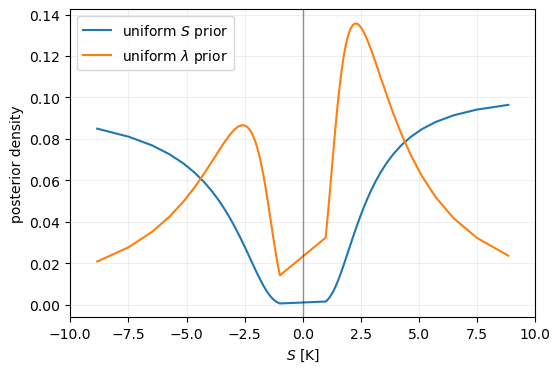

In [220]:
F2x0 = F2x_mc.mean()

S_from_l = -F2x0 / l_grid
ok = np.isfinite(S_from_l) & (S_from_l > -10) & (S_from_l < 10)
ok = ok & (np.abs(S_from_l) > 0.1)

S_plot = S_from_l[ok]
L_plot = likelihood_dN[ok]  # or likelihood_dT[ok]

ii = np.argsort(S_plot)
S_plot = S_plot[ii]
L_plot = L_plot[ii]

## uniform S prior on [-10, 10]: posterior density in S is just L(S), normalized
post_S_uniform_S = L_plot.copy()
post_S_uniform_S = post_S_uniform_S / np.trapz(post_S_uniform_S, S_plot)

## uniform lambda prior: transform p(lambda | data) to p(S | data)
post_S_uniform_lambda = L_plot * F2x0 / S_plot**2
post_S_uniform_lambda = post_S_uniform_lambda / np.trapz(post_S_uniform_lambda, S_plot)

plt.subplots(figsize=(6, 4))
plt.plot(S_plot, post_S_uniform_S, label="uniform $S$ prior")
plt.plot(S_plot, post_S_uniform_lambda, label="uniform $\\lambda$ prior")
plt.axvline(0, color="k", lw=1, alpha=0.4)
plt.xlim(-10, 10)
plt.grid(alpha=0.2)
plt.xlabel("$S$ [K]")
plt.ylabel("posterior density")
plt.legend()
plt.show()

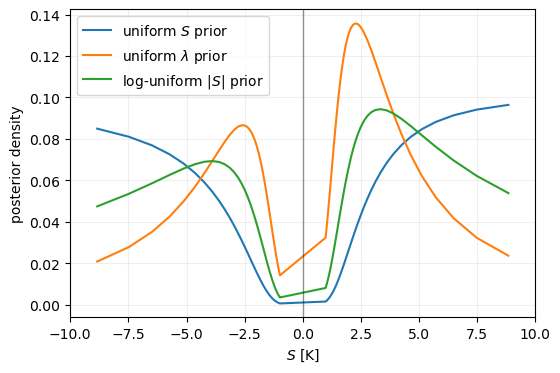

In [221]:
F2x0 = F2x_mc.mean()

S_from_l = -F2x0 / l_grid
ok = np.isfinite(S_from_l) & (S_from_l > -10) & (S_from_l < 10)
ok = ok & (np.abs(S_from_l) > 0.1)

S_plot = S_from_l[ok]
L_plot = likelihood_dN[ok]  # or likelihood_dT[ok]

ii = np.argsort(S_plot)
S_plot = S_plot[ii]
L_plot = L_plot[ii]

## uniform S prior
post_S_uniform_S = L_plot.copy()
post_S_uniform_S = post_S_uniform_S / np.trapz(post_S_uniform_S, S_plot)

## uniform lambda prior
post_S_uniform_lambda = L_plot * F2x0 / S_plot**2
post_S_uniform_lambda = post_S_uniform_lambda / np.trapz(post_S_uniform_lambda, S_plot)

## log-uniform |S| prior: p(S) proportional to 1 / |S|
post_S_log_uniform_absS = L_plot / np.abs(S_plot)
post_S_log_uniform_absS = post_S_log_uniform_absS / np.trapz(
    post_S_log_uniform_absS, S_plot
)

plt.subplots(figsize=(6, 4))
plt.plot(S_plot, post_S_uniform_S, label="uniform $S$ prior")
plt.plot(S_plot, post_S_uniform_lambda, label="uniform $\\lambda$ prior")
plt.plot(S_plot, post_S_log_uniform_absS, label="log-uniform $|S|$ prior")
plt.axvline(0, color="k", lw=1, alpha=0.4)
plt.xlim(-10, 10)
plt.grid(alpha=0.2)
plt.xlabel("$S$ [K]")
plt.ylabel("posterior density")
plt.legend()
plt.show()

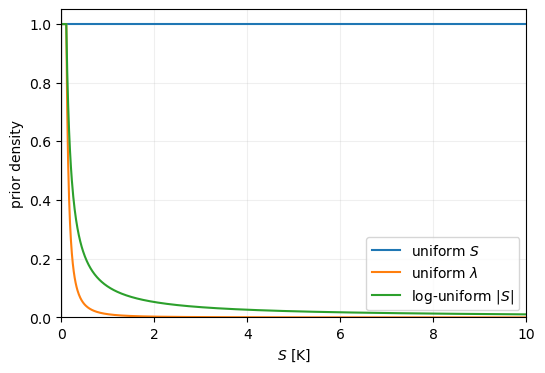

In [225]:
S_prior = np.linspace(-10, 10, 2000)
S_prior = S_prior[np.abs(S_prior) > 0.1]

F2x0 = F2x_mc.mean()

prior_uniform_S = np.ones_like(S_prior)
prior_uniform_lambda = F2x0 / S_prior**2
prior_log_uniform_absS = 1 / np.abs(S_prior)

prior_uniform_S = prior_uniform_S / np.trapz(prior_uniform_S, S_prior)
prior_uniform_lambda = prior_uniform_lambda / np.trapz(prior_uniform_lambda, S_prior)
prior_log_uniform_absS = prior_log_uniform_absS / np.trapz(prior_log_uniform_absS, S_prior)

plt.subplots(figsize=(6, 4))
plt.plot(S_prior, prior_uniform_S/prior_uniform_S.max(), label="uniform $S$")
plt.plot(S_prior, prior_uniform_lambda/prior_uniform_lambda.max(), label="uniform $\\lambda$")
plt.plot(S_prior, prior_log_uniform_absS/prior_log_uniform_absS.max(), label="log-uniform $|S|$")
plt.axvline(0, color="k", lw=1, alpha=0.4)
plt.xlim(0, 10)
plt.ylim(bottom=0)
plt.grid(alpha=0.2)
plt.xlabel("$S$ [K]")
plt.ylabel("prior density")
plt.legend()
plt.show()

In [170]:
print('F (mu and 1sigma), W m-2 dec-1', 10*dFdt_mc.mean().round(3), 10*dFdt_mc.std().round(3))
print('T (mu and 1sigma), T dec-1.   ', 10*dTdt_mc.mean().round(4), 10*dTdt_mc.std().round(3))
print('N (mu and 1sigma), W m-2 dec-1', 10*dNdt_mc.mean().round(3), 10*dNdt_mc.std().round(3))
print('Delta lambda (mu and 1sig), W m-2 K-1', dlamb_mc.mean().round(3), dlamb_mc.std().round(3))

F (mu and 1sigma), W m-2 dec-1 0.56 0.18
T (mu and 1sigma), T dec-1.    0.229 0.05
N (mu and 1sigma), W m-2 dec-1 0.52 0.14
Delta lambda (mu and 1sig), W m-2 K-1 0.0 0.3


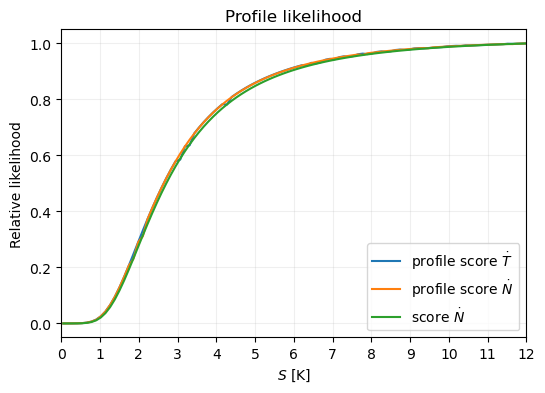

In [171]:
from scipy.optimize import minimize
from scipy.stats import norm

# xmax = 12
S_grid = np.linspace(0.05, xmax, 100)

profile_dN = []
profile_dT = []

for s in S_grid:
    lamb = -3.93 / s

    ## profile likelihood scoring dN, optimizing nuisance F, T, dlambda, F2x
    def nll_dN(theta):
        dF, dT, dlamb, F2x = theta
        lamb_eff = -F2x / s - dlamb
        dN_pred = dF + lamb_eff * dT
        return -(
            norm.logpdf(dF, dFdt_mc.mean(), dFdt_mc.std(ddof=1))
            + norm.logpdf(dT, dTdt_mu, dTdt_sig_adj)
            + norm.logpdf(dlamb, dlamb_mu, dlamb_sig)
            + norm.logpdf(F2x, 3.93, 0.29)
            + norm.logpdf(dNdt_mu, dN_pred, dNdt_sig_adj)
        )

    res = minimize(
        nll_dN,
        x0=[dFdt_mc.mean(), dTdt_mu, dlamb_mu, 3.93],
        method="Nelder-Mead",
    )
    profile_dN.append(np.exp(-res.fun))

    ## profile likelihood scoring dT, optimizing nuisance F, N, dlambda, F2x
    def nll_dT(theta):
        dF, dN, dlamb, F2x = theta
        lamb_eff = -F2x / s - dlamb
        dT_pred = -(dF - dN) / lamb_eff
        return -(
            norm.logpdf(dF, dFdt_mc.mean(), dFdt_mc.std(ddof=1))
            + norm.logpdf(dN, dNdt_mu, dNdt_sig_adj)
            + norm.logpdf(dlamb, dlamb_mu, dlamb_sig)
            + norm.logpdf(F2x, 3.93, 0.29)
            + norm.logpdf(dTdt_mu, dT_pred, dTdt_sig_adj)
        )

    res = minimize(
        nll_dT,
        x0=[dFdt_mc.mean(), dNdt_mu, dlamb_mu, 3.93],
        method="Nelder-Mead",
    )
    profile_dT.append(np.exp(-res.fun))

profile_dN = np.array(profile_dN)
profile_dN = profile_dN / profile_dN.max()

profile_dT = np.array(profile_dT)
profile_dT = profile_dT / profile_dT.max()

plt.subplots(figsize=(6, 4))
plt.plot(S_grid, profile_dT, label="profile score $\\dot{T}$")
plt.plot(S_grid, profile_dN, label="profile score $\\dot{N}$")
plt.plot(S_grid, likelihood_dN, label="score $\dot{N}$")
plt.legend()
plt.grid(alpha=0.2)
plt.xticks(np.arange(xmax + 1))
plt.xlim(0, xmax)
plt.ylabel("Relative likelihood")
plt.xlabel("$S$ [K]")
plt.title("Profile likelihood")
plt.show()

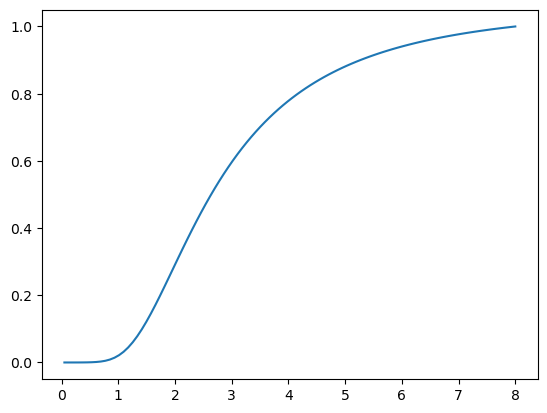

In [172]:
S_grid = np.linspace(0.05, 8, 100)

L = []

for s in S_grid:
    beta = -F2x_mc / s - dlamb_mc

    F_true = dFdt_mc
    T_true = dTdt_mc

    N_true = F_true + beta * T_true

    logp = norm.logpdf(dNdt_mu, loc=N_true, scale=dNdt_sig_adj)

    L.append(np.nanmean(np.exp(logp)))

L = np.array(L)
L = L / L.max()
plt.plot(S_grid,L)

In [192]:
for s in [3, 6, 10]:
    lamb_eff = -F2x_mc / s - dlamb_mc
    dNdt_pred = dFdt_mc + lamb_eff * dTdt_mc
    w = norm.pdf(dNdt_mu, loc=dNdt_pred, scale=dNdt_sig_adj)
    w = w / np.nansum(w)

    print("S =", s)
    print("weighted dF:", np.nansum(w * dFdt_mc) * 10)
    print("weighted dT:", np.nansum(w * dTdt_mc) * 10)
    print("weighted dlambda:", np.nansum(w * dlamb_mc))
    print("weighted F2x:", np.nansum(w * F2x_mc))

S = 3
weighted dF: 0.6911499765295365
weighted dT: 0.21542586747076542
weighted dlambda: -0.08323190182654784
weighted F2x: 3.9042575261948587
S = 6
weighted dF: 0.614573363799251
weighted dT: 0.22555369901900044
weighted dlambda: -0.03970667136663107
weighted F2x: 3.9235438434560233
S = 10
weighted dF: 0.5817759195703087
weighted dT: 0.22770169055365
weighted dlambda: -0.019079067602403698
weighted F2x: 3.9278274169507084


In [193]:
def wq(x, w, q):
    ii = np.argsort(x)
    xs = x[ii]
    ws = w[ii] / np.sum(w[ii])
    return np.interp(q, np.cumsum(ws), xs)

for s in [3, 6, 10]:
    lamb_eff = -F2x_mc / s - dlamb_mc
    dNdt_pred = dFdt_mc + lamb_eff * dTdt_mc
    w = norm.pdf(dNdt_mu, loc=dNdt_pred, scale=dNdt_sig_adj)
    w = w / np.nansum(w)
    ess = 1 / np.nansum(w**2)

    print("S =", s, "ESS =", ess)
    for name, x in [
        ("dF", 10*dFdt_mc),
        ("dT", 10*dTdt_mc),
        ("dlambda", dlamb_mc),
        ("F2x", F2x_mc),
    ]:
        print(name, wq(x, w, 0.05), wq(x, w, 0.50), wq(x, w, 0.95))

S = 3 ESS = 481768.954374535
dF 0.48593123751794864 0.6899519456770931 0.9004999789869426
dT 0.1333027707696997 0.21521406736699056 0.29829427437392375
dlambda -0.5620201289432795 -0.0839365444745387 0.3970669630637039
F2x 3.4286180417012226 3.904150069760172 4.378536865915674
S = 6 ESS = 697361.1860408267
dF 0.4154758218313343 0.6137740178892259 0.8164476375258181
dT 0.1417671463040736 0.2253626915369703 0.30996810365026184
dlambda -0.5135514067645776 -0.0401212773684736 0.4351380814317163
F2x 3.447344237337749 3.9236831445592433 4.39908171071549
S = 10 ESS = 746888.7899721499
dF 0.38390711214571716 0.5810963753911118 0.7815367724794162
dT 0.14354752285507685 0.22755405193306052 0.31243452249910253
dlambda -0.492017709630265 -0.01910661005482184 0.45407146191906267
F2x 3.451342021157157 3.9278553040184123 4.403910021139776


In [196]:
for i, s in [(20, S_grid[20]), (50, S_grid[50]), (90, S_grid[90])]:
    lamb_eff = -F2x_mc / s - dlamb_mc

    dNdt_pred = dFdt_mc + lamb_eff * dTdt_mc
    p_dN = norm.pdf(dNdt_mu, loc=dNdt_pred, scale=dNdt_sig_adj)

    dTdt_pred = -(dFdt_mc - dNdt_mc) / lamb_eff
    p_dT = norm.pdf(dTdt_mu, loc=dTdt_pred, scale=dTdt_sig_adj)

    for name, p in [("dN", p_dN), ("dT", p_dT)]:
        w = p / np.nansum(p)
        ess = 1 / np.nansum(w**2)
        print(i, f"S={s:.2f}", name, "mean", np.nanmean(p), "ESS", ess)

20 S=2.46 dN mean 6.980690960853391 ESS 380263.13332228095
20 S=2.46 dT mean 10.331475534630835 ESS 194380.66961240882
50 S=6.09 dN mean 14.720963565158142 ESS 699609.5924207713
50 S=6.09 dT mean 8.988896739681092 ESS 163815.08919489005
90 S=10.91 dN mean 16.103039501482897 ESS 750761.9284716159
90 S=10.91 dT mean 6.076493102751011 ESS 110934.92789046188


High S fits well if many nuisance draws make:

F - dlambda*T ≈ N_obs
That could happen in two very different ways:

Benign case
A substantial fraction of plausible nuisance draws naturally satisfy the observed N. Then high S is genuinely not penalized by the evidence.

Rescue case
Only tail draws of F, T, or dlambda make N_pred match N_obs. Then the high-S likelihood is being supported by low-prior-density nuisance combinations.

Your marginal likelihood should penalize case 2 because it averages over nuisance draws. But with enough uncertainty in F, T, and dlambda, the “tail” region may still be broad enough that the average remains high.

The profile likelihood is more vulnerable to this because it only asks:
Is there some nuisance combination that fits?

not:
How much plausible nuisance probability mass fits?

So if profile and N-scored marginal look similar, that raises the question you asked: maybe high S is being supported by a relatively narrow favorable nuisance region. But similarity alone does not prove it.

# LGM

## Forcing (ERF)

In [25]:
#SW20 mu
lgm_ice = -3.2
lgm_veg = -1.1
lgm_aer = -1.0
lgm_n2o = -0.28
lgm_ch4 = -0.57
lgm_nonco2 = lgm_ice + lgm_veg + lgm_aer + lgm_ch4 + lgm_n2o
print(lgm_nonco2)

## Revision mu
# lgm_ice = (-3.2 - 2.1)/2 # reduction in forcing: Paleocalibr CESM2 and CESM1.2
# print(lgm_ice)
lgm_ice = -2.65
lgm_veg = -0.5 # -1.1; look at Pliocene veg forcing; significant nonlocal offsets
lgm_aer = -0.5 #-1.0
lgm_n2o = -0.28
lgm_ch4 = -0.57
lgm_nonco2 = lgm_ice + lgm_veg + lgm_aer + lgm_ch4 + lgm_n2o
print(lgm_nonco2)

sig_ice = 0.85*1.5 #T20 spread from PMIP3 and PMIP2 using APRP
sig_veg = 0.57*1.5 # 50% increase
# sig_dust = 1. #0.94 kohler, 1.0 SW20
sig_dust = 1.46 # mahowald
sig_n2o = 0.10
sig_ch4 = 0.05
sig_nonco2 = (sig_ice**2 + sig_veg**2 + sig_dust**2 + sig_ch4**2 + sig_n2o**2)**0.5
sig_nonco2

## note: analysis of pliocene shows land albedo 
## is approx -2.0 W m-2 but cloud adj offsets by ~1.0 Wm-2
## ; this justifies reducing veg forcing

-6.150000000000001
-2.6500000000000004
-4.500000000000001


2.121497112889857

# Pliocene

## ERF

In [40]:
# non-GHG adj. ERFs from the two different methods 
# (Eoi280 vs. Eoi400 - E400) are 
# 1.08/1.26, 1.42/1.66, and 1.73/1.86 W m-2
# for CCSM4, CESM1.2, and CESM26

# range of models and estimatation methods
plio_icevegtopo_1sig = 1.86 - 1.08 # 1.26
print('icevegtopo range = 1sig =', plio_icevegtopo_1sig)

## assume pliocene aerosol unc is 0.5x LGM
plio_aer_1sig = 0.7 #=1.46/2


plio_nonGHG_1sig = (plio_icevegtopo_1sig**2 + plio_aer_1sig**2)**0.5
print('add aer unc, get total', plio_nonGHG_1sig)

## for plio best estimate, take mean of CESM2 and CESM1.2
## use version that accounts for nonlinearity
plio_nonGHG_mu = (1.86+1.66)/2
print(plio_nonGHG_mu)

icevegtopo range = 1sig = 0.78
add aer unc, get total 1.0480458005259121
1.76


In [18]:
np.array([1.08,1.26, 1.42, 1.66, 1.73, 1.86]).mean()

1.5016666666666667

## Correlated pattern effect

In [41]:
import pandas as pd

## pliocene pattern effects digitized from tables s1-s2
plio_dlambda = pd.DataFrame(
    [
        ## table s1, all models
        ("CAM4", "plioDA", -0.57, -0.41),
        ("CAM4", "plioDA: PlioMIP2 Prior", -0.18, -0.02),
        ("CAM4", "Annan24", -0.26, -0.10),
        ("CAM5", "plioDA", -0.48, -0.67),
        ("CAM5", "plioDA: PlioMIP2 Prior", -0.10, -0.29),
        ("CAM5", "Annan24", -0.24, -0.43),
        ("CAM6", "plioDA", -0.69, -1.08),
        ("CAM6", "plioDA: PlioMIP2 Prior", -0.17, -0.56),
        ("CAM6", "Annan24", -0.43, -0.82),
        ("GFDL-AM4", "plioDA", -0.44, -0.37),
        ("GFDL-AM4", "plioDA: PlioMIP2 Prior", -0.12, -0.05),
        ("GFDL-AM4", "Annan24", -0.28, -0.21),
        ("HadGEM3", "plioDA", -0.20, -0.19),
        ("HadGEM3", "plioDA: PlioMIP2 Prior", -0.02, -0.01),
        ("HadGEM3", "Annan24", -0.24, -0.22),

        ## table s2, extra cam4/cam5 patterns
        ("CAM4", "plioDA: PlioVar Data", -0.47, -0.31),
        ("CAM4", "plioDA: Cloud Prior", -0.63, -0.47),
        ("CAM4", "plioDA: 5%", -0.01, 0.16),
        ("CAM4", "plioDA: 95%", -1.01, -0.85),
        ("CAM5", "plioDA: PlioVar Data", -0.43, -0.62),
        ("CAM5", "plioDA: Cloud Prior", -0.56, -0.76),
        ("CAM5", "plioDA: 5%", 0.13, -0.06),
        ("CAM5", "plioDA: 95%", -0.80, -0.99),
    ],
    columns=["model", "pattern", "dlambda_plio", "dlambda_plio_alt"],
)

plio_dlambda

,model,pattern,dlambda_plio,dlambda_plio_alt
0,CAM4,plioDA,-0.57,-0.41
1,CAM4,plioDA: PlioMIP2 Prior,-0.18,-0.02
2,CAM4,Annan24,-0.26,-0.10
3,CAM5,plioDA,-0.48,-0.67
4,CAM5,plioDA: PlioMIP2 Prior,-0.10,-0.29
5,CAM5,Annan24,-0.24,-0.43
6,CAM6,plioDA,-0.69,-1.08
7,CAM6,plioDA: PlioMIP2 Prior,-0.17,-0.56
8,CAM6,Annan24,-0.43,-0.82
9,GFDL-AM4,plioDA,-0.44,-0.37


In [42]:
## lgm pattern effects digitized from tables s1-s2
lgm_dlambda = pd.DataFrame(
    [
        ## table s1, all models
        ("CAM4", "LGMR", -0.45, -0.14),
        ("CAM5", "LGMR", -0.31, -0.35),
        ("CAM6", "LGMR", -0.63, -0.43),
        ("GFDL-AM4", "LGMR", -0.33, -0.22),
        ("HadGEM3", "LGMR", -0.27, -0.25),

        ## table s2, extra cam4/cam5 patterns
        ("CAM4", "lgmDA", -0.69, -0.38),
        ("CAM4", "Amrhein", -0.48, -0.17),
        ("CAM4", "Annan", -0.29, 0.01),
        ("CAM5", "lgmDA", -0.51, -0.55),
        ("CAM5", "Amrhein", -0.33, -0.37),
        ("CAM5", "Annan", -0.09, -0.11),
    ],
    columns=["model", "pattern", "dlambda_lgm", "dlambda_lgm_alt"],
)

lgm_dlambda

,model,pattern,dlambda_lgm,dlambda_lgm_alt
0,CAM4,LGMR,-0.45,-0.14
1,CAM5,LGMR,-0.31,-0.35
2,CAM6,LGMR,-0.63,-0.43
3,GFDL-AM4,LGMR,-0.33,-0.22
4,HadGEM3,LGMR,-0.27,-0.25
5,CAM4,lgmDA,-0.69,-0.38
6,CAM4,Amrhein,-0.48,-0.17
7,CAM4,Annan,-0.29,0.01
8,CAM5,lgmDA,-0.51,-0.55
9,CAM5,Amrhein,-0.33,-0.37


In [43]:
lgm_model_mean = (
    lgm_dlambda
    .groupby("model")[["dlambda_lgm", "dlambda_lgm_alt"]]
    .mean()
)

lgm_model_mean

,dlambda_lgm,dlambda_lgm_alt
model,,
CAM4,-0.4775,-0.170
CAM5,-0.3100,-0.345
CAM6,-0.6300,-0.430
GFDL-AM4,-0.3300,-0.220
HadGEM3,-0.2700,-0.250


## Historical/Pliocene pattern-effect merge

Load OLS historical pattern effects from the flexible-regression long-form table, using `1871-2023` for C25 boundary conditions and `1871-2010` for all other boundary conditions. The table below is joined to the Pliocene `plio_dlambda` table by a common model key, with `HadGEM3-GC31-LL` mapped to `HadGEM3`.

For the across-model comparison, restrict the Pliocene side to the three SST/SIC patterns available for all five models: `plioDA`, `plioDA: PlioMIP2 Prior`, and `Annan24`. `pattern_effect_scatter_rows` keeps row-level combinations for bootstrap/noise checks. `pattern_effect_scatter_model_mean` collapses to model means, which is the safer object for estimating across-model correlation.


In [44]:
## load historical OLS pattern effects and select preferred period by boundary condition

hist_dlambda_path = Path("/glade/u/home/vcooper/work/hist_sst/shortcuts/feedback_longform_from_flexible_ds_regression.csv")
if not hist_dlambda_path.exists():
    hist_dlambda_path = Path("../shortcuts/feedback_longform_from_flexible_ds_regression.csv")

hist_dlambda_raw = pd.read_csv(hist_dlambda_path)

hist_dlambda = hist_dlambda_raw.copy()
hist_dlambda["bc"] = hist_dlambda["bc"].astype(str)
hist_dlambda["years"] = hist_dlambda["years"].astype(str)
hist_dlambda["bc_group"] = np.where(hist_dlambda["bc"].str.startswith("C25"), "C25", hist_dlambda["bc"])
hist_dlambda["scatter_period"] = np.where(hist_dlambda["bc_group"].eq("C25"), "1871-2023", "1871-2010")

hist_dlambda = hist_dlambda.loc[hist_dlambda["years"].eq(hist_dlambda["scatter_period"])].copy()
hist_dlambda["model_common"] = hist_dlambda["model"].replace({"HadGEM3-GC31-LL": "HadGEM3"})
hist_dlambda = hist_dlambda.rename(columns={"lamb_hist": "lambda_hist", "dlamb": "dlambda_hist"})

hist_dlambda = hist_dlambda[
    ["model", "model_common", "bc", "bc_group", "years", "lambda_hist", "dlambda_hist"]
].sort_values(["model_common", "bc_group", "bc"]).reset_index(drop=True)

print(f"loaded {len(hist_dlambda)} selected historical rows from {hist_dlambda_path}")
display(hist_dlambda.head())


loaded 141 selected historical rows from /glade/u/home/vcooper/work/hist_sst/shortcuts/feedback_longform_from_flexible_ds_regression.csv


,model,model_common,bc,bc_group,years,lambda_hist,dlambda_hist
0,CAM4,CAM4,AMIP,AMIP,1871-2010,-2.164900,0.966438
1,CAM4,CAM4,AMIP,AMIP,1871-2010,-2.062464,0.864001
2,CAM4,CAM4,AMIP,AMIP,1871-2010,-2.095380,0.896918
3,CAM4,CAM4,AMIP,AMIP,1871-2010,-2.111972,0.913509
4,CAM4,CAM4,AMIP,AMIP,1871-2010,-1.950775,0.752312


In [45]:
## join historical and pliocene pattern effects by common model, using common pliocene patterns only
common_plio_patterns = ["plioDA", "plioDA: PlioMIP2 Prior", "Annan24"]

plio_dlambda_common = plio_dlambda.loc[
    plio_dlambda["pattern"].isin(common_plio_patterns)
].copy()

plio_pattern_counts = (
    plio_dlambda_common
    .groupby("pattern", observed=True)["model"]
    .nunique()
    .rename("n_models")
)
print("Pliocene patterns retained:")
display(plio_pattern_counts)

plio_dlambda_long = plio_dlambda_common.melt(
    id_vars=["model", "pattern"],
    value_vars=["dlambda_plio", "dlambda_plio_alt"],
    var_name="plio_version",
    value_name="dlambda_plio_value",
).rename(columns={"model": "model_plio", "pattern": "plio_pattern"})

plio_dlambda_long["model_common"] = plio_dlambda_long["model_plio"].replace({"HadGEM3-GC31-LL": "HadGEM3"})

pattern_effect_scatter_rows = hist_dlambda.merge(
    plio_dlambda_long,
    on="model_common",
    how="inner",
)

hist_model_mean = (
    hist_dlambda
    .groupby("model_common", observed=True)
    .agg(
        dlambda_hist_mean=("dlambda_hist", "mean"),
        dlambda_hist_sd=("dlambda_hist", "std"),
        n_hist=("dlambda_hist", "size"),
    )
    .reset_index()
)

plio_model_mean = (
    plio_dlambda_long
    .groupby(["model_common", "plio_version"], observed=True)
    .agg(
        dlambda_plio_mean=("dlambda_plio_value", "mean"),
        dlambda_plio_sd=("dlambda_plio_value", "std"),
        n_plio=("dlambda_plio_value", "size"),
    )
    .reset_index()
)

pattern_effect_scatter_model_mean = hist_model_mean.merge(
    plio_model_mean,
    on="model_common",
    how="inner",
)

print(f"row-level scatter table: {pattern_effect_scatter_rows.shape}")
print(f"model-mean scatter table: {pattern_effect_scatter_model_mean.shape}")
display(pattern_effect_scatter_rows.head())
display(pattern_effect_scatter_model_mean)


Pliocene patterns retained:


pattern
Annan24                   5
plioDA                    5
plioDA: PlioMIP2 Prior    5
Name: n_models, dtype: int64

row-level scatter table: (492, 11)
model-mean scatter table: (10, 8)


,model,model_common,bc,bc_group,years,lambda_hist,dlambda_hist,model_plio,plio_pattern,plio_version,dlambda_plio_value
0,CAM4,CAM4,AMIP,AMIP,1871-2010,-2.1649,0.966438,CAM4,plioDA,dlambda_plio,-0.57
1,CAM4,CAM4,AMIP,AMIP,1871-2010,-2.1649,0.966438,CAM4,plioDA: PlioMIP2 Prior,dlambda_plio,-0.18
2,CAM4,CAM4,AMIP,AMIP,1871-2010,-2.1649,0.966438,CAM4,Annan24,dlambda_plio,-0.26
3,CAM4,CAM4,AMIP,AMIP,1871-2010,-2.1649,0.966438,CAM4,plioDA,dlambda_plio_alt,-0.41
4,CAM4,CAM4,AMIP,AMIP,1871-2010,-2.1649,0.966438,CAM4,plioDA: PlioMIP2 Prior,dlambda_plio_alt,-0.02


,model_common,dlambda_hist_mean,dlambda_hist_sd,n_hist,plio_version,dlambda_plio_mean,dlambda_plio_sd,n_plio
0,CAM4,0.702886,0.201022,25,dlambda_plio,-0.336667,0.205994,3
1,CAM4,0.702886,0.201022,25,dlambda_plio_alt,-0.176667,0.205994,3
2,CAM5,0.635176,0.205645,24,dlambda_plio,-0.273333,0.192180,3
3,CAM5,0.635176,0.205645,24,dlambda_plio_alt,-0.463333,0.192180,3
4,CAM6,0.547745,0.321931,26,dlambda_plio,-0.430000,0.260000,3
5,CAM6,0.547745,0.321931,26,dlambda_plio_alt,-0.820000,0.260000,3
6,GFDL-AM4,0.835774,0.109738,5,dlambda_plio,-0.280000,0.160000,3
7,GFDL-AM4,0.835774,0.109738,5,dlambda_plio_alt,-0.210000,0.160000,3
8,HadGEM3,0.498269,0.223101,2,dlambda_plio,-0.153333,0.117189,3
9,HadGEM3,0.498269,0.223101,2,dlambda_plio_alt,-0.140000,0.113578,3


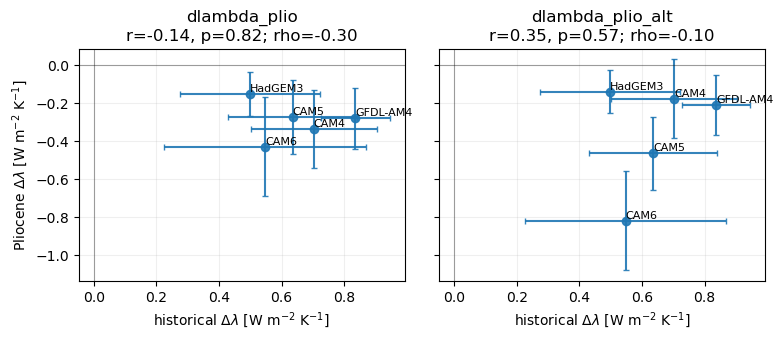

In [46]:
## model-mean correlation check; row-level points are not independent
from scipy.stats import pearsonr, spearmanr

fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharex=True, sharey=True)

for ax, version in zip(axs, ["dlambda_plio", "dlambda_plio_alt"]):
    sub = pattern_effect_scatter_model_mean.query("plio_version == @version").copy()

    x = sub["dlambda_hist_mean"].to_numpy()
    y = sub["dlambda_plio_mean"].to_numpy()
    xerr = sub["dlambda_hist_sd"].fillna(0).to_numpy()
    yerr = sub["dlambda_plio_sd"].fillna(0).to_numpy()

    r, p = pearsonr(x, y)
    rho, p_s = spearmanr(x, y)

    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="o", capsize=2, alpha=0.9)

    for _, row in sub.iterrows():
        ax.text(
            row["dlambda_hist_mean"],
            row["dlambda_plio_mean"],
            row["model_common"],
            fontsize=8,
            ha="left",
            va="bottom",
        )

    ax.axhline(0, color="k", lw=0.8, alpha=0.35)
    ax.axvline(0, color="k", lw=0.8, alpha=0.35)
    ax.grid(alpha=0.2)
    ax.set_title(f"{version}\nr={r:.2f}, p={p:.2f}; rho={rho:.2f}")

axs[0].set_ylabel("Pliocene $\\Delta\\lambda$ [W m$^{-2}$ K$^{-1}$]")
for ax in axs:
    ax.set_xlabel("historical $\\Delta\\lambda$ [W m$^{-2}$ K$^{-1}$]")

plt.tight_layout()
plt.show()


In [48]:
common_models = ["CAM4", "CAM5", "CAM6", "GFDL-AM4", "HadGEM3"]
common_hist_bcs = ["AMIP", "HadISST1"]

hist_common = hist_dlambda.copy()
hist_common = hist_common[hist_common["model_common"].isin(common_models)]
hist_common = hist_common[hist_common["bc"].isin(common_hist_bcs)]
hist_common = hist_common[hist_common["years"].eq("1871-2010")]

display(
    hist_common
    .groupby(["model_common", "bc"], observed=True)["dlambda_hist"]
    .agg(["count", "mean", "std", "min", "max"])
)

count      mean       std       min       max
model_common bc                                                     
CAM4         AMIP          5  0.878635  0.079736  0.752312  0.966438
             HadISST1      1  0.483375       NaN  0.483375  0.483375
CAM5         AMIP          5  0.767740  0.132047  0.547169  0.888570
CAM6         AMIP          1  0.939589       NaN  0.939589  0.939589
             HadISST1      1  0.321128       NaN  0.321128  0.321128
GFDL-AM4     AMIP          1  1.029277       NaN  1.029277  1.029277
             HadISST1      1  0.804610       NaN  0.804610  0.804610
HadGEM3      AMIP          1  0.656025       NaN  0.656025  0.656025
             HadISST1      1  0.340512       NaN  0.340512  0.340512

,r_p05,r_p50,r_p95
plio_version,,,
dlambda_plio,-0.801223,-0.075966,0.733227
dlambda_plio_alt,-0.719345,0.194678,0.848722


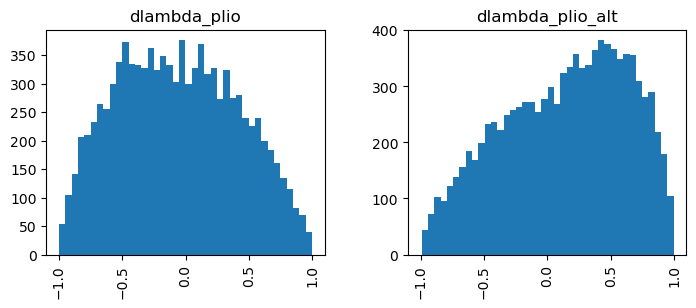

In [49]:
rng = np.random.default_rng(0)

plio_tmp = plio_dlambda.copy()
plio_tmp["model_common"] = plio_tmp["model"].replace({"HadGEM3-GC31-LL": "HadGEM3"})

models = sorted(set(hist_dlambda["model_common"]) & set(plio_tmp["model_common"]))

boot = []
for version in ["dlambda_plio", "dlambda_plio_alt"]:
    for _ in range(10000):
        xs, ys = [], []
        for m in models:
            xs.append(rng.choice(hist_dlambda.loc[hist_dlambda["model_common"].eq(m), "dlambda_hist"]))
            ys.append(rng.choice(plio_tmp.loc[plio_tmp["model_common"].eq(m), version]))
        boot.append((version, np.corrcoef(xs, ys)[0, 1]))

boot = pd.DataFrame(boot, columns=["plio_version", "r"])

display(
    boot.groupby("plio_version")["r"]
    .quantile([0.05, 0.5, 0.95])
    .unstack()
    .rename(columns={0.05: "r_p05", 0.5: "r_p50", 0.95: "r_p95"})
)

boot.hist(column="r", by="plio_version", bins=40, figsize=(8, 3), sharex=True)
plt.show()

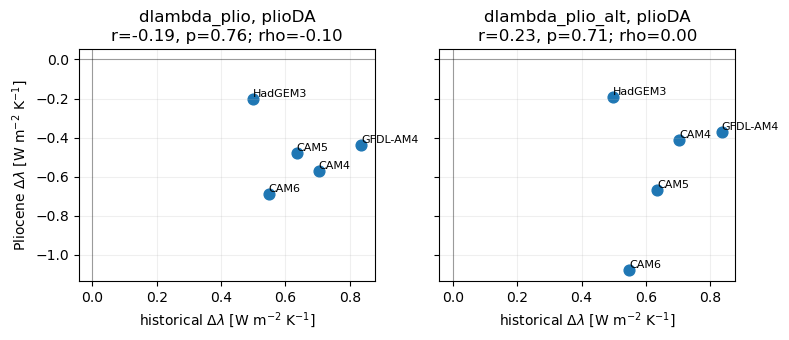

In [50]:
common_plio_patterns = ["plioDA", "plioDA: PlioMIP2 Prior", "Annan24"]
from scipy.stats import pearsonr, spearmanr

## choose one common pattern for the visible scatter
plio_pattern_for_points = "plioDA"  # or "Annan24", "plioDA: PlioMIP2 Prior"

hist_model_mean = (
    hist_dlambda
    .groupby("model_common", observed=True)
    .agg(dlambda_hist_mean=("dlambda_hist", "mean"))
    .reset_index()
)

plio_common = plio_dlambda.loc[
    plio_dlambda["pattern"].isin(common_plio_patterns)
].copy()
plio_common["model_common"] = plio_common["model"].replace({"HadGEM3-GC31-LL": "HadGEM3"})

fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharex=True, sharey=True)

for ax, version in zip(axs, ["dlambda_plio", "dlambda_plio_alt"]):
    plio_points = (
        plio_common
        .query("pattern == @plio_pattern_for_points")
        [["model_common", version]]
        .rename(columns={version: "dlambda_plio_common"})
    )

    sub = hist_model_mean.merge(plio_points, on="model_common", how="inner")

    x = sub["dlambda_hist_mean"]
    y = sub["dlambda_plio_common"]

    r, p = pearsonr(x, y)
    rho, p_s = spearmanr(x, y)

    ax.scatter(x, y, s=60)

    for _, row in sub.iterrows():
        ax.text(row["dlambda_hist_mean"], row["dlambda_plio_common"],
                row["model_common"], fontsize=8, ha="left", va="bottom")

    ax.axhline(0, color="k", lw=0.8, alpha=0.35)
    ax.axvline(0, color="k", lw=0.8, alpha=0.35)
    ax.grid(alpha=0.2)
    ax.set_title(f"{version}, {plio_pattern_for_points}\nr={r:.2f}, p={p:.2f}; rho={rho:.2f}")

axs[0].set_ylabel("Pliocene $\\Delta\\lambda$ [W m$^{-2}$ K$^{-1}$]")
for ax in axs:
    ax.set_xlabel("historical $\\Delta\\lambda$ [W m$^{-2}$ K$^{-1}$]")

plt.tight_layout()
plt.show()

In [51]:
rng = np.random.default_rng(0)

models = sorted(set(hist_dlambda["model_common"]) & set(plio_common["model_common"]))

boot = []
for version in ["dlambda_plio", "dlambda_plio_alt"]:
    for _ in range(10000):
        xs, ys = [], []
        for m in models:
            xs.append(rng.choice(hist_dlambda.loc[hist_dlambda["model_common"].eq(m), "dlambda_hist"]))
            ys.append(rng.choice(plio_common.loc[plio_common["model_common"].eq(m), version]))
        boot.append((version, np.corrcoef(xs, ys)[0, 1]))

boot = pd.DataFrame(boot, columns=["plio_version", "r"])

display(
    boot.groupby("plio_version")["r"]
    .quantile([0.05, 0.5, 0.95])
    .unstack()
    .rename(columns={0.05: "r_p05", 0.5: "r_p50", 0.95: "r_p95"})
)

,r_p05,r_p50,r_p95
plio_version,,,
dlambda_plio,-0.835957,-0.068560,0.771319
dlambda_plio_alt,-0.742048,0.247943,0.882403


# Check Zelinka feedback correlation

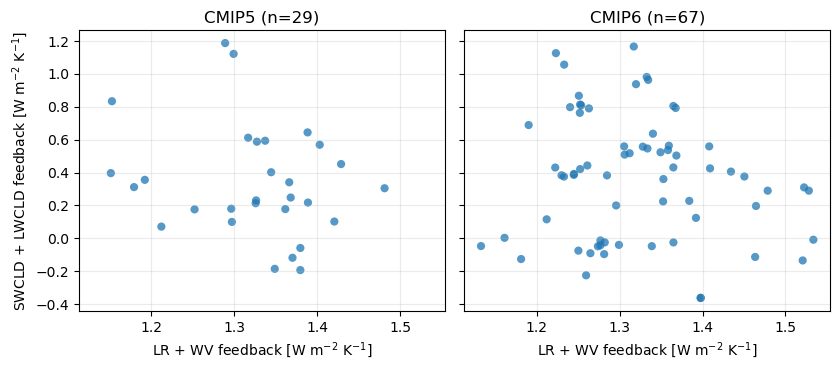

,cmip,model,variant,cloud_total,lr_wv,SWCLD,LWCLD,LR,WV,ECS,PL,ALB,NET
0,CMIP5,ACCESS1-0,r1i1p1,0.401941,1.344715,0.073958,0.327983,-0.421473,1.766188,3.852124,-3.232467,0.473327,-0.764448
1,CMIP5,ACCESS1-3,r1i1p1,0.587814,1.327595,0.479074,0.108740,-0.410799,1.738394,3.547449,-3.269381,0.456915,-0.811022
2,CMIP5,BNU-ESM,r1i1p1,0.102032,1.420856,-0.229415,0.331447,-0.119332,1.540189,4.039458,-3.199480,0.714677,-0.921156
3,CMIP5,CCSM4,r1i1p1,0.177863,1.361775,-0.086979,0.264842,-0.218642,1.580416,2.940467,-3.257869,0.552931,-1.182083
4,CMIP5,CNRM-CM5,r1i1p1,0.099740,1.297415,-0.212677,0.312417,-0.317632,1.615047,3.251813,-3.258868,0.503291,-1.134964


In [18]:
## zelinka cmip5/cmip6 cloud vs lr+wv feedbacks
import json
from pathlib import Path

zelinka_candidates = [
    Path("data/zelinka_cmip/cmip56_forcing_feedback_ecs.json"),
    Path("../data/zelinka_cmip/cmip56_forcing_feedback_ecs.json"),
    Path("/glade/u/home/vcooper/work/hist_sst/data/zelinka_cmip/cmip56_forcing_feedback_ecs.json"),
]
zelinka_path = next(path for path in zelinka_candidates if path.exists())

with open(zelinka_path, "r") as f:
    zelinka = json.load(f)

rows = []
for cmip_version in ["CMIP5", "CMIP6"]:
    for model, variants in zelinka[cmip_version].items():
        for variant, vals in variants.items():
            rows.append(
                {
                    "cmip": cmip_version,
                    "model": model,
                    "variant": variant,
                    "cloud_total": vals["SWCLD"] + vals["LWCLD"],
                    "lr_wv": vals["LR"] + vals["WV"],
                    "SWCLD": vals["SWCLD"],
                    "LWCLD": vals["LWCLD"],
                    "LR": vals["LR"],
                    "WV": vals["WV"],
                    "ECS": vals["ECS"],
                    "PL": vals['PL'],
                    "ALB": vals['ALB'],
                    "NET": vals['NET'],
                }
            )

zelinka_feedbacks = pd.DataFrame(rows)

fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.8), sharex=True, sharey=True)

for ax, cmip_version in zip(axs, ["CMIP5", "CMIP6"]):
    sub = zelinka_feedbacks.query("cmip == @cmip_version")
    ax.scatter(
        sub["lr_wv"],
        sub["cloud_total"],
        s=35,
        alpha=0.75,
        edgecolor="none",
    )
    # ax.axhline(0, color="k", lw=0.8, alpha=0.35)
    # ax.axvline(0, color="k", lw=0.8, alpha=0.35)
    ax.grid(alpha=0.25)
    ax.set_title(f"{cmip_version} (n={len(sub)})")
    ax.set_xlabel("LR + WV feedback [W m$^{-2}$ K$^{-1}$]")

axs[0].set_ylabel("SWCLD + LWCLD feedback [W m$^{-2}$ K$^{-1}$]")
plt.tight_layout()
plt.show()

zelinka_feedbacks.head()


In [22]:
varlist = ["PL", "cloud_total", "ALB", "lr_wv"]

# rows = []
# for cmip_version in ["CMIP5", "CMIP6"]:
#     for model, variants in zelinka[cmip_version].items():
#         for variant, vals in variants.items():
#             rows.append(
#                 {
#                     "cmip": cmip_version,
#                     "model": model,
#                     "variant": variant,
#                     **{v: vals[v] for v in varlist},
#                 }
#             )

# fbk_df = pd.DataFrame(rows)

# corr_cmip5 = fbk_df.query("cmip == 'CMIP5'")[varlist].corr()
# corr_cmip6 = fbk_df.query("cmip == 'CMIP6'")[varlist].corr()

corr_cmip5 = zelinka_feedbacks.query("cmip == 'CMIP5'")[varlist].corr()
corr_cmip6 = zelinka_feedbacks.query("cmip == 'CMIP6'")[varlist].corr()


display(corr_cmip5.style.background_gradient(cmap="bwr", vmin=-1, vmax=1).format("{:.2f}"))
display(corr_cmip6.style.background_gradient(cmap="bwr", vmin=-1, vmax=1).format("{:.2f}"))

,PL,cloud_total,ALB,lr_wv
PL,1.00,-0.43,0.17,-0.11
cloud_total,-0.43,1.00,-0.35,-0.22
ALB,0.17,-0.35,1.00,0.35
lr_wv,-0.11,-0.22,0.35,1.00


,PL,cloud_total,ALB,lr_wv
PL,1.00,-0.43,0.21,-0.08
cloud_total,-0.43,1.00,0.15,-0.14
ALB,0.21,0.15,1.00,0.38
lr_wv,-0.08,-0.14,0.38,1.00


In [70]:
ecs = zelinka_feedbacks.query("cmip == 'CMIP6'")['ECS']
net = zelinka_feedbacks.query("cmip == 'CMIP6'")['NET']
cld = zelinka_feedbacks.query("cmip == 'CMIP6'")['cloud_total']

ecs = zelinka_feedbacks['ECS']
net = zelinka_feedbacks['NET']
cld = zelinka_feedbacks['cloud_total']

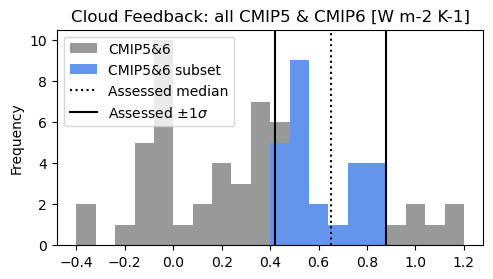

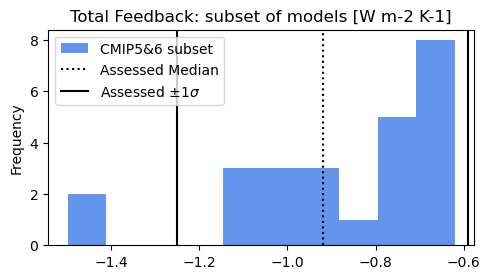

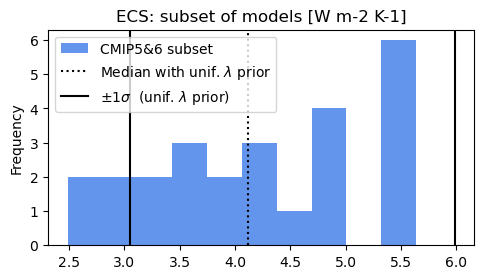

In [69]:
cldmean = 0.65
sig = 0.23

plt.subplots(figsize=(5.5,2.8))
plt.title('Cloud Feedback: all CMIP5 & CMIP6 [W m-2 K-1]')
cld.plot.hist(bins=20,color='0.6',label='CMIP5&6',range=[-0.4,1.2])
cld.where((cld < cldmean+sig) & (cld > cldmean-sig)).plot.hist(bins=20,color='cornflowerblue', label='CMIP5&6 subset',range=[-0.4,1.2])
plt.axvline(cldmean-sig*0,c='k',ls=':',label='Assessed median')
plt.axvline(cldmean-sig,c='k')
plt.axvline(cldmean+sig,c='k',label='Assessed $\pm 1\sigma$')
plt.legend()
plt.show()

# plt.title('ECS: subset of models')
# ecs.where((cld < cldmean+sig) & (cld > cldmean-sig)).plot.hist(color='0.2',label='CMIP5&6 subset')
# plt.show()

plt.subplots(figsize=(5.5,2.8))
plt.title('Total Feedback: subset of models [W m-2 K-1]')
net.where((cld < cldmean+sig) & (cld > cldmean-sig)).plot.hist(color='cornflowerblue', label='CMIP5&6 subset')
plt.axvline(-0.92,c='k',ls=':',label='Assessed Median')
plt.axvline(-0.92-0.33,c='k')
plt.axvline(-0.92+0.33,c='k',label='Assessed $\pm 1\sigma$')
plt.legend()
plt.show()

plt.subplots(figsize=(5.5,2.8))
plt.title('ECS: subset of models [W m-2 K-1]')
# ecs.where((ecs < -3.93/(-0.92-0.33)) & (ecs > -3.93/(-0.92+0.33))).plot.hist(color='cornflowerblue', label='CMIP5&6 subset')
ecs.where((cld < cldmean+sig) & (cld > cldmean-sig)).plot.hist(color='cornflowerblue', label='CMIP5&6 subset')
plt.axvline(4.12,c='k',ls=':',label='Median with unif. $\lambda$ prior')
plt.axvline(3.05,c='k')
plt.axvline(5.99,c='k',label='$\pm 1\sigma$  (unif. $\lambda$ prior)')
# uniform lambda prior: {5: 2.54, 17: 3.05, 50: 4.12, 83: 5.99, 95: 7.92}
plt.legend()
plt.show()

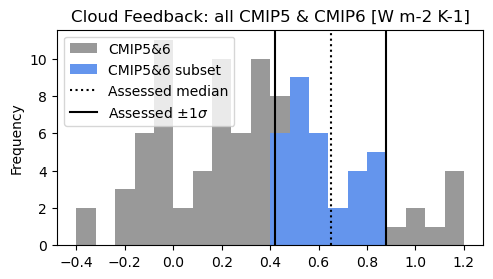

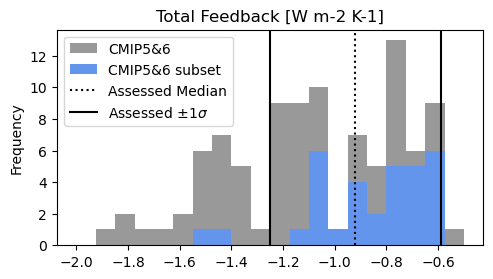

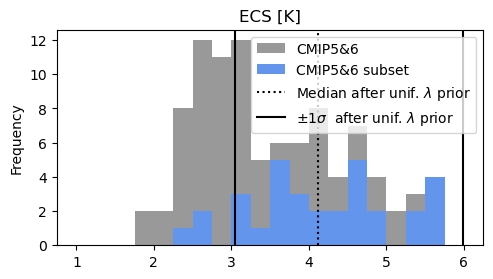

In [81]:
cldmean = 0.65
sig = 0.23

plt.subplots(figsize=(5.5,2.8))
plt.title('Cloud Feedback: all CMIP5 & CMIP6 [W m-2 K-1]')
cld.plot.hist(bins=20,color='0.6',label='CMIP5&6',range=[-0.4,1.2])
cld.where((cld < cldmean+sig) & (cld > cldmean-sig)).plot.hist(bins=20,color='cornflowerblue', label='CMIP5&6 subset',range=[-0.4,1.2])
plt.axvline(cldmean-sig*0,c='k',ls=':',label='Assessed median')
plt.axvline(cldmean-sig,c='k')
plt.axvline(cldmean+sig,c='k',label='Assessed $\pm 1\sigma$')
plt.legend()
plt.show()

# plt.title('ECS: subset of models')
# ecs.where((cld < cldmean+sig) & (cld > cldmean-sig)).plot.hist(color='0.2',label='CMIP5&6 subset')
# plt.show()

plt.subplots(figsize=(5.5,2.8))
plt.title('Total Feedback [W m-2 K-1]')
net.plot.hist(label='CMIP5&6',color='0.6',range=[-2.,-0.5],bins=20)
net.where((cld < cldmean+sig) & (cld > cldmean-sig)).plot.hist(color='cornflowerblue', label='CMIP5&6 subset',range=[-2.,-0.5],bins=20)
plt.axvline(-0.92,c='k',ls=':',label='Assessed Median')
plt.axvline(-0.92-0.33,c='k')
plt.axvline(-0.92+0.33,c='k',label='Assessed $\pm 1\sigma$')
plt.legend()
plt.show()

plt.subplots(figsize=(5.5,2.8))
plt.title('ECS [K]')
ecs.plot.hist(color='0.6', label='CMIP5&6', range=[1.,6.],bins=20)
ecs.where((cld < cldmean+sig) & (cld > cldmean-sig)).plot.hist(color='cornflowerblue', label='CMIP5&6 subset', range=[1.,6.],bins=20)
plt.axvline(4.12,c='k',ls=':',label='Median after unif. $\lambda$ prior')
plt.axvline(3.05,c='k')
plt.axvline(5.99,c='k',label='$\pm 1\sigma$  after unif. $\lambda$ prior')
# uniform lambda prior: {5: 2.54, 17: 3.05, 50: 4.12, 83: 5.99, 95: 7.92}
plt.legend()
plt.show()